## Imports and Setup

In [29]:
#Core libraries
import pandas as pd
import numpy as np
# XGBoost
from xgboost import XGBRegressor
# Scikit-learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# Model persistence
import joblib
# Plotting
import matplotlib.pyplot as plt
# Reproducibility
RANDOM_STATE = 42

import json

## Load Featured Dataset

In [30]:
df = pd.read_csv(
    "../../data/processed/feature_engineered_unscaled.csv",
    parse_dates=[0],
    index_col=0
)

df = df.sort_index()
df.head()

,demand,demand_diff,lag_1,lag_48,rolling_mean_48,hour,day_of_week,month
timestamp,,,,,,,,
2009-01-02 00:00:00,30659.0,732.0,29927.0,33939.0,33459.395833,0,4,1
2009-01-02 00:30:00,30506.0,-153.0,30659.0,34072.0,33385.104167,0,4,1
2009-01-02 01:00:00,30171.0,-335.0,30506.0,33615.0,33313.354167,1,4,1
2009-01-02 01:30:00,29443.0,-728.0,30171.0,32526.0,33249.125000,1,4,1
2009-01-02 02:00:00,29273.0,-170.0,29443.0,31877.0,33194.875000,2,4,1


## Select Features and Target

In [31]:
target = "demand"

features = [
    "lag_1",
    "lag_48",
    "rolling_mean_48",
    "hour",
    "day_of_week",
    "month"
]

df = df.dropna()

X = df[features]
y = df[target]

## Train-Test Split

In [32]:
# Fixed split used across ALL models (ARIMA, XGBoost, LSTM)
SPLIT_RATIO = 0.8

split_idx = int(len(df) * SPLIT_RATIO)
SPLIT_TIMESTAMP = df.index[split_idx]

print(f"Official train-test split timestamp: {SPLIT_TIMESTAMP}")

Official train-test split timestamp: 2021-11-16 14:00:00


## Apply the Split

In [33]:
train_df = df.loc[:SPLIT_TIMESTAMP]
test_df = df.loc[SPLIT_TIMESTAMP:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

## Hyperparamter Tuning with GridSearchCV

In [34]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

## Evaluate XGBoost

In [35]:
best_xgb = grid_search.best_estimator_

# Print the best hyperparameters found by GridSearchCV
print("Best Hyperparameters found by GridSearch:")
print(grid_search.best_params_)

preds = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost MAPE: {mape:.4f} ({mape*100:.2f}%)")

Best Hyperparameters found by GridSearch:
{'learning_rate': 0.1, 'n_estimators': 200}
XGBoost RMSE: 404.44
XGBoost MAE: 272.99
XGBoost MAPE: 0.0116 (1.16%)


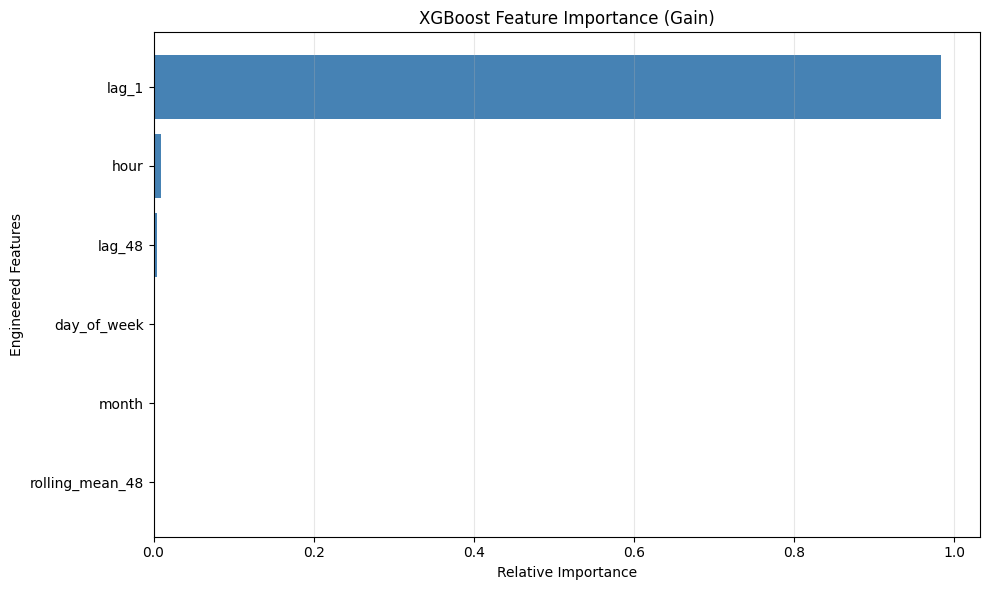

In [36]:
# Plot Feature Importance
plt.figure(figsize=(10, 6))
# Get feature importances from the best model
importances = best_xgb.feature_importances_

# Sort features by importance
indices = np.argsort(importances)
sorted_features = [features[i] for i in indices]

plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), sorted_features)
plt.title("XGBoost Feature Importance (Gain)")
plt.xlabel("Relative Importance")
plt.ylabel("Engineered Features")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

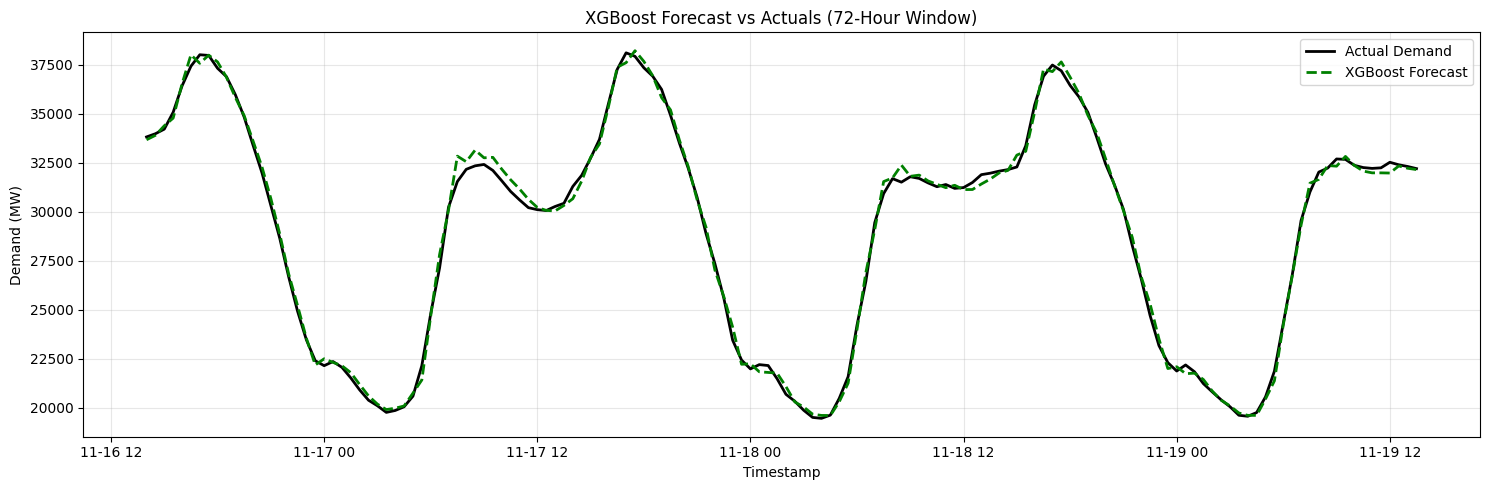

In [40]:
# Micro-Level Plot 
window = 144 

plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:window], y_test.iloc[:window], label="Actual Demand", color='black', linewidth=2)
plt.plot(y_test.index[:window], preds[:window], label="XGBoost Forecast", color='green', linestyle="--", linewidth=2)
plt.title("XGBoost Forecast vs Actuals (72-Hour Window)")
plt.ylabel("Demand (MW)")
plt.xlabel("Timestamp")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# Save metrics to a JSON file
xgb_results = {
    'model_name': 'XGBoost',
    'rmse': float(rmse),
    'mae': float(mae),
    'mape' : float(mape)
}

with open('../results/xgb_metrics.json', 'w') as f:
    json.dump(xgb_results, f)
    
# Optional: Save predictions for the evaluation plot later
np.save('../results/xgb_preds.npy', preds[:100]) # Save first 100 for plotting

# Save the Model

In [39]:
joblib.dump(
    best_xgb,
    "xgb_model.pkl"
)

['xgb_model.pkl']